In [1]:
import pandas as pd

df = pd.read_csv("../data/sample_music_context.csv")
df.head()


,user_id,track_id,track_name,artist,danceability,energy,valence,tempo,activity_tag,emotion_tag,time_of_day,liked,skipped,replayed
0,u001,t001,Song A,Artist A,0.72,0.81,0.65,120,workout,happy,morning,1,0,1
1,u002,t002,Song B,Artist B,0.45,0.38,0.30,80,study,calm,night,1,0,0
2,u003,t003,Song C,Artist C,0.60,0.70,0.55,100,commute,focus,afternoon,0,1,0
3,u004,t004,Song D,Artist D,0.30,0.25,0.20,70,night,sad,night,1,0,1
4,u005,t005,Song E,Artist E,0.85,0.90,0.80,128,party,happy,night,1,0,1


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       5 non-null      str    
 1   track_id      5 non-null      str    
 2   track_name    5 non-null      str    
 3   artist        5 non-null      str    
 4   danceability  5 non-null      float64
 5   energy        5 non-null      float64
 6   valence       5 non-null      float64
 7   tempo         5 non-null      int64  
 8   activity_tag  5 non-null      str    
 9   emotion_tag   5 non-null      str    
 10  time_of_day   5 non-null      str    
 11  liked         5 non-null      int64  
 12  skipped       5 non-null      int64  
 13  replayed      5 non-null      int64  
dtypes: float64(3), int64(4), str(7)
memory usage: 692.0 bytes


In [3]:
df.describe()

,danceability,energy,valence,tempo,liked,skipped,replayed
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.584000,0.608000,0.500000,99.600000,0.800000,0.200000,0.600000
std,0.216864,0.280482,0.247487,24.915858,0.447214,0.447214,0.547723
min,0.300000,0.250000,0.200000,70.000000,0.000000,0.000000,0.000000
25%,0.450000,0.380000,0.300000,80.000000,1.000000,0.000000,0.000000
50%,0.600000,0.700000,0.550000,100.000000,1.000000,0.000000,1.000000
75%,0.720000,0.810000,0.650000,120.000000,1.000000,0.000000,1.000000
max,0.850000,0.900000,0.800000,128.000000,1.000000,1.000000,1.000000


Matplotlib is building the font cache; this may take a moment.


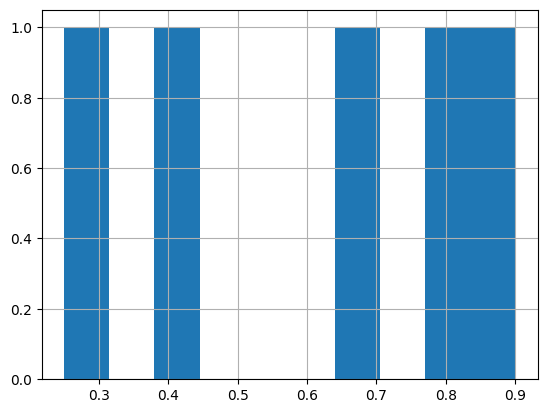

In [4]:
import matplotlib.pyplot as plt

df["energy"].hist()
plt.show()

In [5]:
df["liked"].value_counts()

liked
1    4
0    1
Name: count, dtype: int64

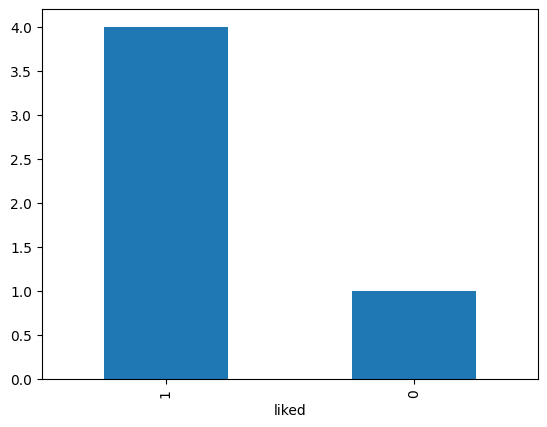

In [6]:
df["liked"].value_counts().plot(kind="bar")
plt.show()


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X=df[["danceability","energy","valence","tempo"]]
y=df["liked"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model=RandomForestClassifier()
model.fit(X_train,y_train)

print(model.score(X_test,y_test))

1.0


In [9]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

model.fit(X_train,y_train)

print("Accuracy:",model.score(X_test,y_test))

Accuracy: 1.0


In [10]:
X=df[[
"danceability",
"energy",
"valence",
"tempo",
"activity_tag",
"emotion_tag",
"time_of_day"
]]

In [12]:
context_df = pd.get_dummies(
    df[[
        "activity_tag",
        "emotion_tag",
        "time_of_day"
    ]]
)

context_df.head()

,activity_tag_commute,activity_tag_night,activity_tag_party,activity_tag_study,activity_tag_workout,emotion_tag_calm,emotion_tag_focus,emotion_tag_happy,emotion_tag_sad,time_of_day_afternoon,time_of_day_morning,time_of_day_night
0,False,False,False,False,True,False,False,True,False,False,True,False
1,False,False,False,True,False,True,False,False,False,False,False,True
2,True,False,False,False,False,False,True,False,False,True,False,False
3,False,True,False,False,False,False,False,False,True,False,False,True
4,False,False,True,False,False,False,False,True,False,False,False,True


In [13]:
music_df=df[[
    "danceability",
    "energy",
    "valence",
    "tempo"
]]

X=pd.concat(
    [music_df,context_df],
    axis=1
)

y=df["liked"]

X.head()

,danceability,energy,valence,tempo,activity_tag_commute,activity_tag_night,activity_tag_party,activity_tag_study,activity_tag_workout,emotion_tag_calm,emotion_tag_focus,emotion_tag_happy,emotion_tag_sad,time_of_day_afternoon,time_of_day_morning,time_of_day_night
0,0.72,0.81,0.65,120,False,False,False,False,True,False,False,True,False,False,True,False
1,0.45,0.38,0.30,80,False,False,False,True,False,True,False,False,False,False,False,True
2,0.60,0.70,0.55,100,True,False,False,False,False,False,True,False,False,True,False,False
3,0.30,0.25,0.20,70,False,True,False,False,False,False,False,False,True,False,False,True
4,0.85,0.90,0.80,128,False,False,True,False,False,False,False,True,False,False,False,True
